2.17 sec
torch.Size([32, 1, 64, 64]) torch.float32 torch.Size([32]) torch.int64


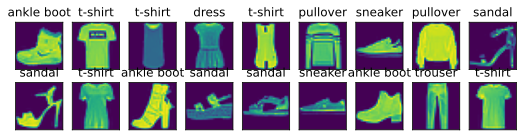

In [2]:
# 这是一个 Jupyter Notebook 的“魔法命令”，作用是让 matplotlib 绘制的图形直接内嵌在 Notebook 的输出区域。
%matplotlib inline
# 导入 PyTorch 核心库
import torch
# 导入 torchvision，它包含了计算机视觉相关的数据集、模型和图像转换工具。
import torchvision
# 从 PyTorch 的工具模块中导入 data，主要为了使用 DataLoader。
from torch.utils import data
# 从 torchvision 中导入 transforms，用于对图像进行预处理。
from torchvision import transforms
# 导入《动手学深度学习》这本书配套的辅助库，并简写为 d2l，方便调用。
from d2l import torch as d2l

# 调用 d2l 库的函数，设置所有 matplotlib 图像都以 SVG (可缩放矢量图形) 格式显示。
# SVG 格式的图片在放大时不会变模糊，更加清晰。
d2l.use_svg_display() # 将 matplotlib 的输出设置为 SVG 格式
# --- 数据加载与预处理 ---

# 1. 创建一个 ToTensor 转换器实例。
#    - 它会将 PIL 格式的图片（像素值范围 0-255）转换成 PyTorch 的 Tensor（张量）。
#    - 同时，它会自动将像素值从 [0, 255] 的整数范围归一化到 [0.0, 1.0] 的浮点数范围。
#    - 并且，它会调整图像的维度顺序，从 [高, 宽, 通道] 调整为 PyTorch 习惯的 [通道, 高, 宽]。
trans = transforms.ToTensor()

# 2. 加载 Fashion-MNIST 训练数据集。
mnist_train = torchvision.datasets.FashionMNIST(
    root="../data",  # 指定数据集下载和存放的目录（上一级目录的 data 文件夹）。
    train=True,  # 指明加载的是训练集。
    transform=trans,  # 对每一张图片都应用上面定义的 `trans` 转换。
    download=True)  # 如果在 `root` 目录找不到数据集，就自动从网上下载。

# 3. 加载 Fashion-MNIST 测试数据集。
mnist_test = torchvision.datasets.FashionMNIST(
    root="../data",
    train=False,  # 指明加载的是测试集。
    transform=trans,
    download=True)
# --- 检查数据形状 ---

# mnist_train[0] 会获取第一个样本，它是一个元组 (image, label)。
# mnist_train[0][0] 则是获取第一个样本的图像部分。
# .shape 用于查看这个图像张量的形状。
# 输出会是 torch.Size([1, 28, 28])，代表 [通道数, 高度, 宽度]。
mnist_train[0][0].shape


# --- 辅助函数：将数字标签转换为文本标签 ---

def get_fashion_mnist_labels(labels):  #@save
    """
    输入一个包含数字标签的列表或张量，返回其对应的文本标签列表。
    例如，输入 [0, 1, 2]，返回 ['t-shirt', 'trouser', 'pullover']。
    """
    # ✨ 优化建议: 对于这种固定不变的序列，使用元组(Tuple)比列表(List)更好。
    # 元组是不可变的，意图更明确，且在某些情况下性能略好。
    # text_labels = ('t-shirt', 'trouser', 'pullover', 'dress', 'coat',
    #                'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot')
    text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
                   'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']

    # 使用列表推导式，高效地完成转换。
    return [text_labels[int(i)] for i in labels]


# --- 辅助函数：可视化图像列表 ---

def show_images(imgs, num_rows, num_cols, titles=None, scale=1.0):  #@save
    #imgs：torch.Tensor取出的图像,表示要显示的图像集合。
    #num_rows:指定在图像网格中要显示的 行数。
    # num_cols指定在图像网格中要显示的 列数。
    #titles:用于在每张图上方显示标题,可以是 list[str]（字符串列表）
    #scale:控制整个图像网格的缩放比例
    """在一个网格中绘制图像列表。"""
    # 计算整个图床的大小，使其与行列数和缩放比例相适应。
    figsize = (num_cols * scale, num_rows * scale)
    # 创建一个 num_rows * num_cols 的子图网格，可以根据行列数自动调整画布大小，让每张图片都能清晰显示。
    _, axes = d2l.plt.subplots(num_rows, num_cols, figsize=figsize)
    #变量名 _ 通常表示：“只是一个占位符”；并不会实际使用
    # 将 axes 这个二维数组“压平”成一维数组，方便后续用一个 for 循环来处理所有子图。
    axes = axes.flatten()
    # 同时遍历子图坐标轴(ax)和图像(img)。
    for i, (ax, img) in enumerate(zip(axes, imgs)):  # enumerate: 同时返回索引和值; zip: 将 axes 和 imgs 成对配对; for i, (ax, img): 解包每对元素
        if torch.is_tensor(img):
            # 如果是 PyTorch 张量，需要先转为 NumPy 数组才能被 matplotlib 显示。
            ax.imshow(img.numpy())
            #把一个 PyTorch 张量 (img) 转换成 NumPy 数组，然后使用 Matplotlib 的 imshow() 方法把它显示为图像。
        else:
            # 如果是 PIL 图片，直接显示。
            ax.imshow(img)
        # 隐藏每个子图的 x 轴和 y 轴刻度，让图像更美观。
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        # 如果提供了标题列表，则为每个子图设置标题。
        if titles:
            ax.set_title(titles[i])
    return axes


# --- 可视化一个批次的数据以验证加载是否正确 ---

# 1. 创建一个临时的 DataLoader，设置批大小为 18。
# 2. `iter()` 将其变为迭代器，`next()` 取出第一个批次的数据。
#    X 是图像张量，形状为 [18, 1, 28, 28]；y 是标签张量，形状为 [18]。
X, y = next(iter(data.DataLoader(mnist_train, batch_size=18)))

# 3. 调用 show_images 函数进行可视化。
#    - X.reshape(18, 28, 28): 将图像张量从 [18, 1, 28, 28] 变为 [18, 28, 28]，以匹配 imshow 的输入要求。
#    - 2, 9: 以 2 行 9 列的网格显示。
#    - titles=get_fashion_mnist_labels(y): 将数字标签 y 转换为文本标签作为标题。
show_images(X.reshape(18, 28, 28), 2, 9, titles=get_fashion_mnist_labels(y));
# --- 创建正式的数据加载器 (DataLoader) ---

# 设置批大小，表示在训练时，模型每次处理 256 张图片。
batch_size = 256


def get_dataloader_workers(default_workers=4):  #@save
    """
    智能地获取用于数据加载的子进程数量。
    这是一个非常好的实践，让代码具有更好的可移植性和性能。
    """
    import os
    # 尝试获取系统的 CPU 核心数。如果成功，就使用它；如果失败（在某些特殊环境下），则回退到默认值。
    return os.cpu_count() if os.cpu_count() is not None else default_workers


# 创建用于训练的数据加载器。
train_iter = data.DataLoader(
    mnist_train,
    batch_size=256,       # 增大批大小
    shuffle=True,
    num_workers=4,    )# 使用多进程
# 参数解释:
# - mnist_train: 数据源。
# - batch_size: 批大小。
# - shuffle=True: 非常重要！在每个训练周期（epoch）开始时，打乱整个数据集的顺序。
#                 这能增加训练的随机性，防止模型学到数据的排列顺序，有助于提升模型泛化能力。
# - num_workers: 使用多个子进程来并行加载数据，可以极大地加速数据读取，避免 CPU 成为训练瓶颈。
# --- 测试数据加载速度 ---

# 创建一个 d2l 库里的计时器。
timer = d2l.Timer()
# 遍历整个 train_iter 一遍。`continue` 表示循环体里什么都不做。
# 这个循环的目的纯粹是为了测试把所有数据从硬盘读取到内存并完成预处理需要多长时间。
for X, y in train_iter:
    continue
# 停止计时器，并用 f-string 格式化输出所用时间，保留两位小数。
print(f'{timer.stop():.2f} sec')


# --- 封装所有数据加载逻辑到一个函数中 ---
# 这是一个非常好的编程习惯，让代码更模块化、更易于复用。

def load_data_fashion_mnist(batch_size, resize=None):  #@save
    """下载Fashion-MNIST数据集，然后将其加载到内存中，并返回训练和测试的数据加载器。"""
    # 初始化一个转换操作列表。
    trans = [transforms.ToTensor()]
    # 如果用户指定了 resize 参数（例如，resize=64），
    if resize:
        # 就在转换列表的最前面插入一个 Resize 操作。顺序很重要，要先调整大小，再转成张量。
        trans.insert(0, transforms.Resize(resize))
    # 使用 Compose 将列表中的多个转换操作组合成一个单一的转换管道。
    trans = transforms.Compose(trans)

    # 使用组合好的 `trans` 来加载训练集和测试集。
    mnist_train = torchvision.datasets.FashionMNIST(
        root="../data", train=True, transform=trans, download=True)
    mnist_test = torchvision.datasets.FashionMNIST(
        root="../data", train=False, transform=trans, download=True)

    # 返回训练集和测试集的数据加载器。
    # 注意：训练加载器 shuffle=True，测试加载器 shuffle=False（测试时不需要打乱顺序）。
    return (data.DataLoader(mnist_train, batch_size, shuffle=True,
                            num_workers=get_dataloader_workers()),
            data.DataLoader(mnist_test, batch_size, shuffle=False,
                            num_workers=get_dataloader_workers()))


# --- 调用封装函数并验证 ---

# 调用刚刚封装好的函数，获取批大小为 32、并且所有图片都被缩放到了 64x64 的数据加载器。
train_iter, test_iter = load_data_fashion_mnist(32, resize=64)

# 遍历训练数据加载器，只取第一个批次。
for X, y in train_iter:
    # 打印第一个批次的图像张量 `X` 和标签张量 `y` 的形状和数据类型，以作验证。
    # 预期输出:
    # X.shape -> torch.Size([32, 1, 64, 64]) (批大小, 通道, 高, 宽)
    # X.dtype -> torch.float32
    # y.shape -> torch.Size([32])
    # y.dtype -> torch.int64
    print(X.shape, X.dtype, y.shape, y.dtype)
    # `break` 让我们在打印完第一个批次后就跳出循环，这是一个快速验证的常用技巧。
    break